# BioLACE vs RCTD: Spatial Clustering and Metrics

This notebook compares **BioLACE** (ours) against **RCTD** on Slide-seq data.

We:

1. Load spatial coordinates, RCTD cell-type assignments, and BioLACE cluster labels.
2. Align barcodes across all sources.
3. Compute **Adjusted Rand Index (ARI)** and **V-measure** between BioLACE clusters and RCTD labels.
4. Visualize:
   - Global spatial cluster maps (BioLACE vs RCTD).
   - Side-by-side highlight plots for selected cluster pairs.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import mmread
from sklearn.metrics import adjusted_rand_score, v_measure_score

# Paths
OURS_LABELS_CSV = "../BioLACE_results/ours_v1_labels.csv"
COORDS_CSV      = "../slidedeq_data/slideseqv1_mc_coords_filtered.csv"
RCTD_WEIGHTS_TXT = "../slidedeq_dat/slideseqv1_mc_RCTDweights.txt"

# Helpers
def load_coords(coords_csv: str) -> pd.DataFrame:
    """
    Load Slide-seq bead coordinates and standardize to columns:
        index: barcode (string)
        columns: ['xcoord', 'ycoord']
    Tries several common x/y column name conventions.
    """
    d = pd.read_csv(coords_csv, index_col=0)
    cols_l = [c.lower() for c in d.columns]
    candidates = [
        ("xcoord", "ycoord"),
        ("x", "y"),
        ("x_pos", "y_pos"),
        ("posx", "posy"),
        ("pixel_x", "pixel_y"),
        ("px", "py"),
    ]
    xcol = ycol = None
    for xc, yc in candidates:
        if xc in cols_l and yc in cols_l:
            xcol = d.columns[cols_l.index(xc)]
            ycol = d.columns[cols_l.index(yc)]
            break

    # Fallback: first two numeric columns
    if xcol is None or ycol is None:
        num_cols = d.select_dtypes(include=[np.number]).columns
        if len(num_cols) >= 2:
            xcol, ycol = num_cols[0], num_cols[1]
        else:
            raise KeyError("Cannot detect x/y columns in coords CSV.")

    out = d[[xcol, ycol]].copy()
    out.columns = ["xcoord", "ycoord"]
    out.index = out.index.astype(str)
    return out

def build_color_map_from_labels(labels: np.ndarray, palette_name: str = "tab20"):
    """
    Build a stable color map for a set of categorical labels.
    Returns:
        colors: np.ndarray of hex colors aligned with `labels`
        label_to_color: dict mapping label -> hex color
    Clusters are sorted by frequency so "major" clusters get distinct colors.
    """
    uniq, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)       
    uniq_ordered = uniq[order]

    n_clusters = len(uniq_ordered)
    n_pool = max(20, n_clusters * 2) 

    cmap = plt.get_cmap(palette_name, n_pool)
    pool_colors = [plt.matplotlib.colors.to_hex(cmap(i)) for i in range(n_pool)]

    used = set()
    label_to_color = {}
    for lab in uniq_ordered:
        color = next((c for c in pool_colors if c not in used), "#BBBBBB")
        label_to_color[lab] = color
        used.add(color)

    colors = np.array([label_to_color.get(lbl, "#BBBBBB") for lbl in labels])
    return colors, label_to_color


In [ ]:
# Load coords and RCTD
coords = load_coords(COORDS_CSV)
# RCTD weights: rows = barcodes (aligned with coords index order),
# columns = reference cell types / clusters
W = np.asarray(mmread(RCTD_WEIGHTS_TXT).todense(), dtype=float)
W = W / (W.sum(axis=1, keepdims=True) + 1e-12)  # row-normalize
rctd_hard = W.argmax(axis=1).astype(str)

rctd_series = pd.Series(rctd_hard, index=coords.index, name="rctd_label")

# BioLACE labels
ours_df = pd.read_csv(OURS_LABELS_CSV)
if not {"barcode", "label"}.issubset(ours_df.columns):
    raise ValueError("BioLACE label CSV must contain 'barcode' and 'label' columns.")

ours_df["barcode"] = ours_df["barcode"].astype(str)
ours_df["label"] = ours_df["label"].astype(str)
ours_series = ours_df.set_index("barcode")["label"]
ours_series.name = "biolace_label"

# Align barcodes
common_barcodes = coords.index.intersection(ours_series.index)
if len(common_barcodes) == 0:
    raise ValueError("No overlap between coordinates and BioLACE cluster labels.")

coords_sub = coords.loc[common_barcodes]
ours_sub   = ours_series.loc[common_barcodes]
rctd_sub   = rctd_series.loc[common_barcodes]

print(f"[INFO] # common barcodes used for comparison: {len(common_barcodes)}")


[INFO] # common barcodes used for comparison: 9930


Clustering metrics (BioLACE vs. RCTD)

In [ ]:
# Clustering metrics
ari = adjusted_rand_score(ours_sub.values, rctd_sub.values)
vms = v_measure_score(ours_sub.values, rctd_sub.values)

print("\n=== BioLACE vs RCTD: Global Clustering Concordance ===")
print(f"Adjusted Rand Index (ARI):   {ari:.3f}")
print(f"V-measure:                   {vms:.3f}")



=== BioLACE vs RCTD: Global Clustering Concordance ===
Adjusted Rand Index (ARI):   0.445
V-measure:                   0.377


Spatial clustering (BioLACE vs. RCTD)

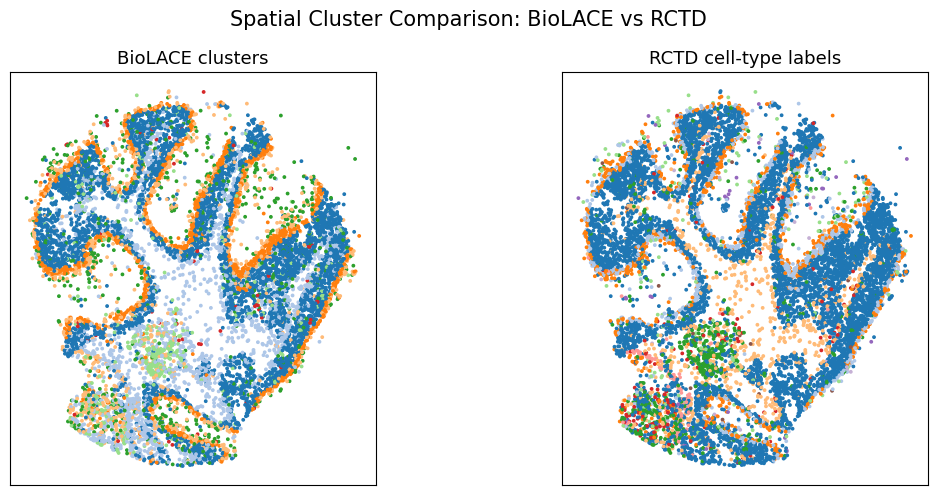

In [ ]:
# Plotting
ours_colors, ours_cmap  = build_color_map_from_labels(ours_sub.values,  palette_name="tab20")
rctd_colors, rctd_cmap  = build_color_map_from_labels(rctd_sub.values, palette_name="tab20")
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
s = 3

# BioLACE clusters
axs[0].scatter(
    coords_sub["xcoord"], coords_sub["ycoord"],
    c=ours_colors, s=s, rasterized=True
)
axs[0].set_title("BioLACE clusters", fontsize=13)
axs[0].invert_yaxis()
axs[0].set_xticks([]); axs[0].set_yticks([])
axs[0].set_aspect("equal")

# RCTD clusters
axs[1].scatter(
    coords_sub["xcoord"], coords_sub["ycoord"],
    c=rctd_colors, s=s, rasterized=True
)
axs[1].set_title("RCTD cell-type labels", fontsize=13)
axs[1].invert_yaxis()
axs[1].set_xticks([]); axs[1].set_yticks([])
axs[1].set_aspect("equal")

fig.suptitle("Spatial Cluster Comparison: BioLACE vs RCTD", fontsize=15)
plt.tight_layout()
plt.show()


Per-cluster comparison plots (BioLACE vs. RCTD)

In the paper, we did this comparison for Slideseq-V2 data -- here we demonstrate this test for Slideseq-V1.


=== Per-cluster spatial comparison (BioLACE vs RCTD) ===
  Pair BioLACE=0 (n=4333) vs RCTD=0 (n=6075)


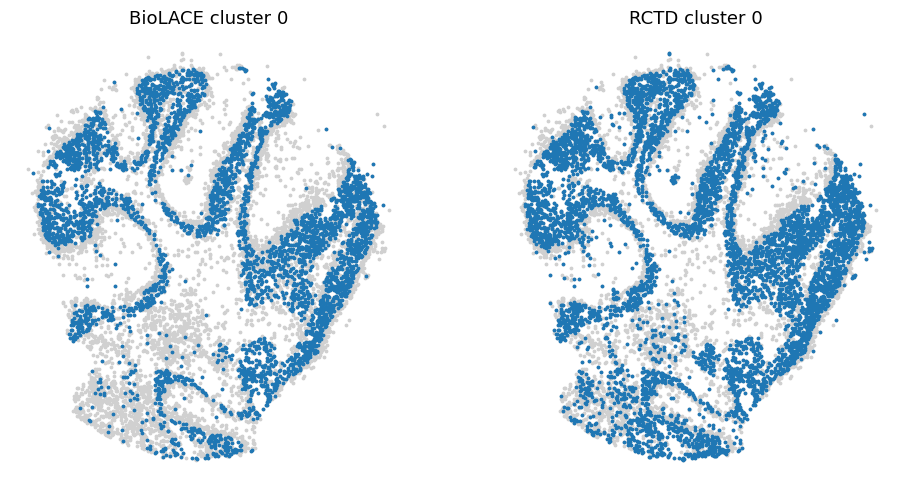

  Pair BioLACE=1 (n=1831) vs RCTD=5 (n=761)


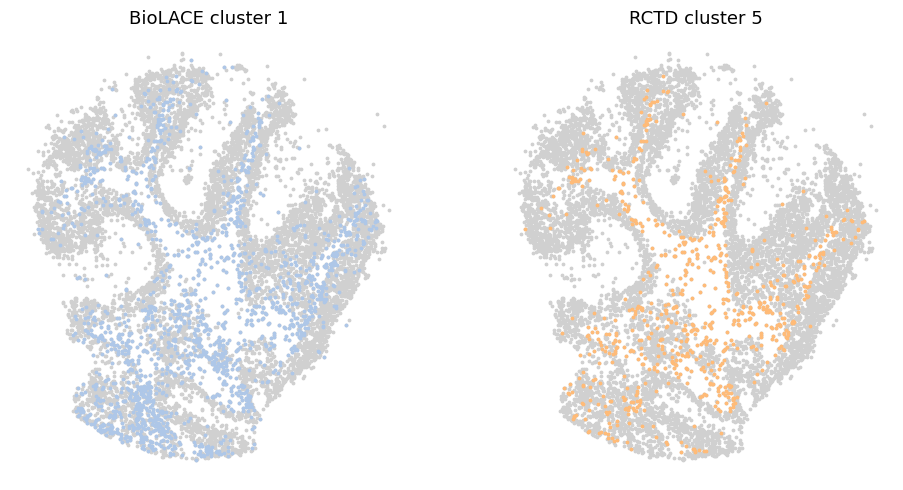

  Pair BioLACE=4 (n=1299) vs RCTD=1 (n=1026)


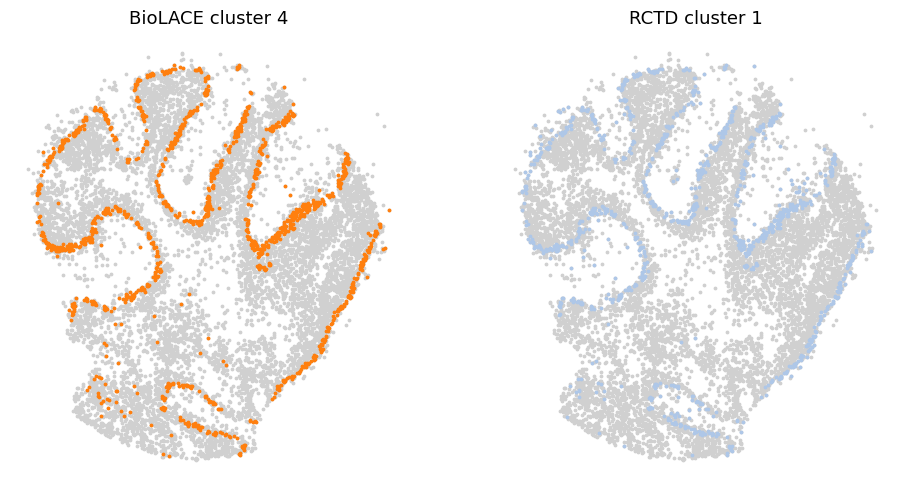

In [ ]:
# Per-cluster comparison plots: BioLACE vs RCTD
cluster_pairs = [
    ("0", "0"),  # Granular layer
    ("1", "5"),  # Oligodendrocytes
    ("4", "1"),  # Purkinje
]

light_gray = "#D0D0D0"

print("\n=== Per-cluster spatial comparison (BioLACE vs RCTD) ===")
for ours_cl, rctd_cl in cluster_pairs:
    mask_ours = (ours_sub.values == ours_cl)
    mask_rctd = (rctd_sub.values == rctd_cl)

    n_ours = mask_ours.sum()
    n_rctd = mask_rctd.sum()
    print(f"  Pair BioLACE={ours_cl} (n={n_ours}) vs RCTD={rctd_cl} (n={n_rctd})")

    fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

    # BioLACE highlight
    axs[0].scatter(
        coords_sub["xcoord"], coords_sub["ycoord"],
        s=3, c=light_gray, rasterized=True
    )
    axs[0].scatter(
        coords_sub["xcoord"][mask_ours],
        coords_sub["ycoord"][mask_ours],
        s=3,
        c=ours_cmap.get(ours_cl, "#1f77b4"),
        rasterized=True,
    )
    axs[0].set_title(f"BioLACE cluster {ours_cl}", fontsize=13)
    axs[0].set_aspect("equal")
    axs[0].axis("off")

    # RCTD highlight
    axs[1].scatter(
        coords_sub["xcoord"], coords_sub["ycoord"],
        s=3, c=light_gray, rasterized=True
    )
    axs[1].scatter(
        coords_sub["xcoord"][mask_rctd],
        coords_sub["ycoord"][mask_rctd],
        s=3,
        c=rctd_cmap.get(rctd_cl, "#1f77b4"),
        rasterized=True,
    )
    axs[1].set_title(f"RCTD cluster {rctd_cl}", fontsize=13)
    axs[1].set_aspect("equal")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


## Interpretation

- **Global metrics** (ARI, V-measure) quantify the agreement between BioLACE clusters and RCTD cell-type labels.
- **Spatial maps** show that BioLACE:
  - Recovers laminar structure and major domains that visually align with RCTD.
  - Sometimes refines or splits RCTD regions into more coherent subdomains (see per-cluster comparisons).

These plots and scores are what we reference in the paper when we compare BioLACE’s clustering
to RCTD label transfer on Slide-seq V1.
